In [7]:
import json
import os
import math
from collections import Counter

from pyvis.network import Network
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx

In [8]:
# ---------------------------------------------------------------------------
# Paleta Steam
# ---------------------------------------------------------------------------
STEAM_DARK   = "#1b2838"
STEAM_BLUE   = "#66c0f4"
STEAM_MID    = "#2a475e"
STEAM_GREEN  = "#4fa83d"
STEAM_RED    = "#c44e52"
STEAM_GREY   = "#8f98a0"
STEAM_WHITE  = "#c6d4df"

In [9]:
# ===========================================================================
# FUNÇÃO DE CARREGAMENTO
# ===========================================================================

def carregar_grafo(
    nodes_path:    str = "nodes.json",
    edges_path:    str = "edges.json",
    edge_types:    list = None,   # None = todos; ou ["review"], ["comment"], ["review","comment"]
    directed:      bool = True,
) -> nx.DiGraph | nx.Graph:
    """
    Lê nodes.json e edges.json (gerados por build_graph.py) e monta um grafo NetworkX.

    Parâmetros
    ----------
    nodes_path  : caminho para o arquivo de nós
    edges_path  : caminho para o arquivo de arestas
    edge_types  : lista de tipos a incluir ("review", "comment"). None = todos.
    directed    : True → DiGraph (padrão, respeita a direcionalidade)
                  False → Graph  (não dirigido, para análises que exigem isso)

    Retorna
    -------
    G : nx.DiGraph ou nx.Graph com atributos nos nós e arestas.

    Atributos dos NÓS
    -----------------
    - review_count  : quantas reviews o usuário fez
    - comment_count : quantos comentários recebeu no perfil

    Atributos das ARESTAS
    ---------------------
    - type     : "review" ou "comment"
    - game     : ID do jogo (só arestas review)
    - src_date : data da review mais antiga (só arestas review)
    - dst_date : data da review mais nova   (só arestas review)
    """
    for path in (nodes_path, edges_path):
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Arquivo '{path}' não encontrado.\n"
                "Gere os arquivos primeiro com: python build_graph.py steam_data.jsonl"
            )

    edge_types = set(edge_types) if edge_types else None

    G = nx.DiGraph() if directed else nx.Graph()

    # --- Nós ---
    print(f"Carregando nós de '{nodes_path}' ...")
    with open(nodes_path, encoding="utf-8") as f:
        nodes = json.load(f)

    for n in nodes:
        G.add_node(
            n["id"],
            review_count=n.get("review_count", 0),
            comment_count=n.get("comment_count", 0),
        )
    print(f"  {G.number_of_nodes():,} nós adicionados.")

    # --- Arestas ---
    print(f"Carregando arestas de '{edges_path}' ...")
    with open(edges_path, encoding="utf-8") as f:
        edges = json.load(f)

    added = 0
    for e in edges:
        etype = e.get("type", "")
        if edge_types and etype not in edge_types:
            continue
        attrs = {k: v for k, v in e.items() if k not in ("src", "dst")}
        G.add_edge(e["src"], e["dst"], **attrs)
        added += 1

    print(f"  {added:,} arestas adicionadas.")
    print(f"  Grafo {'dirigido' if directed else 'não dirigido'} pronto.\n")
    return G

In [10]:
# ===========================================================================
# ANÁLISE DE ESTATÍSTICAS
# ===========================================================================

def analisar_estatisticas_grafo(G: nx.DiGraph | nx.Graph):
    """
    Imprime estatísticas gerais e plota o histograma de graus.
    Funciona tanto com DiGraph quanto com Graph.
    """
    eh_dirigido = G.is_directed()

    print("\n" + "=" * 50)
    print("  ESTATÍSTICAS GERAIS DO GRAFO")
    print("=" * 50)

    num_nos     = G.number_of_nodes()
    num_arestas = G.number_of_edges()
    print(f"Total de nós   (usuários):   {num_nos:>10,}")
    print(f"Total de arestas (conexões): {num_arestas:>10,}")

    if num_nos == 0:
        print("Grafo vazio!")
        return

    # --- Graus ---
    if eh_dirigido:
        in_deg  = [d for _, d in G.in_degree()]
        out_deg = [d for _, d in G.out_degree()]
        graus   = [i + o for i, o in zip(in_deg, out_deg)]  # grau total
        print(f"\nGrau médio de entrada:  {sum(in_deg)  / num_nos:.2f}")
        print(f"Grau médio de saída:    {sum(out_deg) / num_nos:.2f}")
        print(f"Grau total médio:       {sum(graus)   / num_nos:.2f}")
        print(f"Grau máximo (total):    {max(graus)}")
    else:
        graus = [d for _, d in G.degree()]
        print(f"\nGrau médio:  {sum(graus) / num_nos:.2f}")
        print(f"Grau máximo: {max(graus)}")

    # --- Densidade ---
    densidade = nx.density(G)
    print(f"\nDensidade da rede: {densidade:.8f}")

    # --- Componentes ---
    if eh_dirigido:
        comp_fracos  = nx.number_weakly_connected_components(G)
        print(f"Componentes fracamente conectados: {comp_fracos:,}")
    else:
        comp = nx.number_connected_components(G)
        print(f"Componentes conectados: {comp:,}")

    # --- Clustering (só faz sentido em grafos não dirigidos grandes; usa approximation) ---
    try:
        G_und = G.to_undirected() if eh_dirigido else G
        if num_nos <= 50_000:
            clust = nx.average_clustering(G_und)
            print(f"Coef. de agrupamento médio: {clust:.6f}")
        else:
            import random
            sample = random.sample(list(G_und.nodes()), 5_000)
            clust = nx.average_clustering(G_und, nodes=sample)
            print(f"Coef. de agrupamento médio (amostra 5k nós): {clust:.6f}")
    except Exception as exc:
        print(f"Clustering: não calculado ({exc})")

    # --- Top hubs ---
    print("\n--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---")
    hubs = sorted(
        ((no, G.in_degree(no) + G.out_degree(no)) if eh_dirigido else (no, G.degree(no))
         for no in G.nodes()),
        key=lambda x: x[1], reverse=True
    )[:10]
    for steam_id, grau in hubs:
        dados = G.nodes[steam_id]
        print(f"  ID: {steam_id:<22} | Grau: {grau:>6} "
              f"| Reviews: {dados.get('review_count',0):>4} "
              f"| Comentários recebidos: {dados.get('comment_count',0):>4}")

    # --- Contagem de tipos de arestas ---
    tipos = Counter(d.get("type", "?") for _, _, d in G.edges(data=True))
    print("\n--- ARESTAS POR TIPO ---")
    for t, cnt in tipos.most_common():
        print(f"  {t}: {cnt:,}")

    # --- Histograma ---
    _plotar_histograma_graus(graus, eh_dirigido, in_deg if eh_dirigido else None,
                             out_deg if eh_dirigido else None)


def _plotar_histograma_graus(graus, eh_dirigido, in_deg=None, out_deg=None):
    if eh_dirigido and in_deg is not None:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))
        fig.patch.set_facecolor(STEAM_DARK)

        datasets = [
            (graus,   "Grau Total",   STEAM_BLUE),
            (in_deg,  "Grau de Entrada (in-degree)",  STEAM_GREEN),
            (out_deg, "Grau de Saída (out-degree)", STEAM_RED),
        ]
        for ax, (data, label, cor) in zip(axs, datasets):
            ax.set_facecolor(STEAM_MID)
            ax.hist(data, bins=60, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
            ax.set_title(label, color=STEAM_WHITE, fontsize=13, fontweight="bold")
            ax.set_xlabel("Grau", color=STEAM_GREY)
            ax.set_ylabel("Frequência", color=STEAM_GREY)
            ax.tick_params(colors=STEAM_GREY)
            ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
            for spine in ax.spines.values():
                spine.set_edgecolor(STEAM_GREY)
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor(STEAM_DARK)
        ax.set_facecolor(STEAM_MID)
        ax.hist(graus, bins=60, color=STEAM_BLUE, edgecolor=STEAM_DARK, alpha=0.85)
        ax.set_xlabel("Grau (Número de Conexões)", color=STEAM_GREY)
        ax.set_ylabel("Frequência (Número de Usuários)", color=STEAM_GREY)
        ax.tick_params(colors=STEAM_GREY)
        ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
        for spine in ax.spines.values():
            spine.set_edgecolor(STEAM_GREY)

    fig.suptitle(
        "Distribuição de Graus — Rede Steam",
        color=STEAM_WHITE, fontsize=15, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()


# ===========================================================================
# ANÁLISES EXTRAS
# ===========================================================================

def plotar_analises_extras(G: nx.DiGraph | nx.Graph, amostra_grafo: int = 500):
    """
    Plota 4 painéis:
      1. Histograma de reviews por usuário
      2. Histograma de comentários recebidos por usuário
      3. Top 15 jogos com mais conexões de review
      4. Visualização da rede (subamostra para não travar)

    Parâmetros
    ----------
    G            : grafo carregado por carregar_grafo()
    amostra_grafo: quantos nós usar na visualização topológica (painel 4).
                   Reduza se estiver lento; aumente se quiser mais detalhe.
    """
    eh_dirigido = G.is_directed()

    # --- Coleta atributos ---
    review_counts  = []
    comment_counts = []

    for no, dados in G.nodes(data=True):
        review_counts.append(dados.get("review_count", 0))
        comment_counts.append(dados.get("comment_count", 0))

    # --- Contagem de jogos nas arestas de review ---
    game_counter = Counter(
        d["game"]
        for _, _, d in G.edges(data=True)
        if d.get("type") == "review" and "game" in d
    )

    # --- Layout da figura ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle(
        "Análise da Rede de Usuários Steam",
        color=STEAM_WHITE, fontsize=16, fontweight="bold",
    )

    _estilizar_ax = lambda ax, titulo, xlabel, ylabel: (
        ax.set_facecolor(STEAM_MID),
        ax.set_title(titulo, color=STEAM_WHITE, fontsize=12, fontweight="bold"),
        ax.set_xlabel(xlabel, color=STEAM_GREY, fontsize=10),
        ax.set_ylabel(ylabel, color=STEAM_GREY, fontsize=10),
        ax.tick_params(colors=STEAM_GREY),
        ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY),
        [s.set_edgecolor(STEAM_GREY) for s in ax.spines.values()],
    )

    # --- Painel 1: Reviews por usuário ---
    ax1 = axs[0, 0]
    ax1.set_facecolor(STEAM_MID)
    ax1.hist(
        [r for r in review_counts if r > 0],
        bins=50, color=STEAM_BLUE, edgecolor=STEAM_DARK, alpha=0.85,
    )
    _estilizar_ax(ax1, "Distribuição de Reviews por Usuário",
                  "Número de Reviews", "Quantidade de Usuários")
    media_rev = sum(review_counts) / len(review_counts) if review_counts else 0
    ax1.axvline(media_rev, color=STEAM_RED, linestyle="--", linewidth=1.5,
                label=f"Média: {media_rev:.1f}")
    ax1.legend(facecolor=STEAM_DARK, labelcolor=STEAM_WHITE)

    # --- Painel 2: Comentários recebidos por usuário ---
    ax2 = axs[0, 1]
    ax2.set_facecolor(STEAM_MID)
    ax2.hist(
        [c for c in comment_counts if c > 0],
        bins=50, color=STEAM_GREEN, edgecolor=STEAM_DARK, alpha=0.85,
    )
    _estilizar_ax(ax2, "Comentários Recebidos por Usuário",
                  "Número de Comentários Recebidos", "Quantidade de Usuários")
    media_com = sum(comment_counts) / len(comment_counts) if comment_counts else 0
    ax2.axvline(media_com, color=STEAM_RED, linestyle="--", linewidth=1.5,
                label=f"Média: {media_com:.1f}")
    ax2.legend(facecolor=STEAM_DARK, labelcolor=STEAM_WHITE)

    # --- Painel 3: Top 15 jogos mais conectados ---
    ax3 = axs[1, 0]
    ax3.set_facecolor(STEAM_MID)
    if game_counter:
        top_games = game_counter.most_common(15)
        jogos  = [f"App {g[0]}" for g in top_games]
        conts  = [g[1] for g in top_games]
        bars   = ax3.barh(jogos[::-1], conts[::-1], color=STEAM_BLUE,
                          edgecolor=STEAM_DARK, alpha=0.85)
        # Rótulos nas barras
        for bar, val in zip(bars, conts[::-1]):
            ax3.text(bar.get_width() + max(conts) * 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:,}", va="center", color=STEAM_WHITE, fontsize=8)
        _estilizar_ax(ax3, "Top 15 Jogos por Conexões de Review",
                      "Número de Arestas de Review", "App ID do Jogo")
    else:
        ax3.text(0.5, 0.5, "Sem arestas de review no grafo",
                 ha="center", va="center", color=STEAM_GREY, fontsize=12)
        ax3.set_title("Top 15 Jogos por Conexões de Review",
                      color=STEAM_WHITE, fontsize=12, fontweight="bold")

    # --- Painel 4: Visualização topológica (subamostra) ---
    ax4 = axs[1, 1]
    ax4.set_facecolor(STEAM_DARK)
    ax4.set_title(
        f"Topologia da Rede (amostra: {amostra_grafo} nós)",
        color=STEAM_WHITE, fontsize=12, fontweight="bold",
    )
    ax4.axis("off")

    nos_todos = list(G.nodes())
    if len(nos_todos) > amostra_grafo:
        import random
        random.seed(42)
        nos_sample = random.sample(nos_todos, amostra_grafo)
    else:
        nos_sample = nos_todos

    G_sub = G.subgraph(nos_sample)

    graus_sub = (
        {n: G_sub.in_degree(n) + G_sub.out_degree(n) for n in G_sub.nodes()}
        if eh_dirigido
        else dict(G_sub.degree())
    )
    tamanhos = [max(graus_sub.get(n, 1) * 8, 10) for n in G_sub.nodes()]

    pos = nx.spring_layout(G_sub, seed=42, k=0.5)
    nx.draw_networkx_nodes(
        G_sub, pos, ax=ax4, node_size=tamanhos,
        node_color=STEAM_BLUE, alpha=0.75,
    )
    nx.draw_networkx_edges(
        G_sub, pos, ax=ax4,
        alpha=0.15, edge_color=STEAM_GREY, width=0.5,
        arrows=eh_dirigido, arrowsize=6,
    )

    plt.tight_layout()
    plt.show()


# ===========================================================================
# BÔNUS: Análise de comunidades (por tipo de aresta)
# ===========================================================================

def plotar_distribuicao_tipos(G: nx.DiGraph | nx.Graph):
    """
    Plota pizza e barras comparando arestas de review vs comentário,
    e mostra grau médio separado por tipo.
    """
    review_edges  = [(u, v) for u, v, d in G.edges(data=True) if d.get("type") == "review"]
    comment_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("type") == "comment"]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle("Composição das Arestas do Grafo", color=STEAM_WHITE,
                 fontsize=15, fontweight="bold")

    # Pizza
    ax1 = axs[0]
    ax1.set_facecolor(STEAM_DARK)
    valores = [len(review_edges), len(comment_edges)]
    labels  = [f"Review\n{len(review_edges):,}", f"Comentário\n{len(comment_edges):,}"]
    cores   = [STEAM_BLUE, STEAM_GREEN]
    wedges, texts, autotexts = ax1.pie(
        valores, labels=labels, colors=cores, autopct="%1.1f%%",
        startangle=90, textprops={"color": STEAM_WHITE},
        wedgeprops={"edgecolor": STEAM_DARK, "linewidth": 2},
    )
    for at in autotexts:
        at.set_color(STEAM_DARK)
        at.set_fontweight("bold")
    ax1.set_title("Proporção por Tipo", color=STEAM_WHITE, fontsize=12, fontweight="bold")

    # Grau médio por tipo
    ax2 = axs[1]
    ax2.set_facecolor(STEAM_MID)

    G_rev = nx.DiGraph()
    G_rev.add_edges_from(review_edges)
    G_com = nx.DiGraph()
    G_com.add_edges_from(comment_edges)

    categorias = ["Review\n(out)", "Review\n(in)", "Comentário\n(out)", "Comentário\n(in)"]
    medias = [
        sum(d for _, d in G_rev.out_degree()) / max(G_rev.number_of_nodes(), 1),
        sum(d for _, d in G_rev.in_degree())  / max(G_rev.number_of_nodes(), 1),
        sum(d for _, d in G_com.out_degree()) / max(G_com.number_of_nodes(), 1),
        sum(d for _, d in G_com.in_degree())  / max(G_com.number_of_nodes(), 1),
    ]
    cores_bar = [STEAM_BLUE, STEAM_BLUE, STEAM_GREEN, STEAM_GREEN]
    alphas    = [0.9, 0.5, 0.9, 0.5]

    for i, (cat, med, cor, alp) in enumerate(zip(categorias, medias, cores_bar, alphas)):
        bar = ax2.bar(cat, med, color=cor, alpha=alp, edgecolor=STEAM_DARK)
        ax2.text(i, med + max(medias) * 0.01, f"{med:.2f}",
                 ha="center", color=STEAM_WHITE, fontsize=10, fontweight="bold")

    ax2.set_title("Grau Médio por Tipo de Aresta", color=STEAM_WHITE,
                  fontsize=12, fontweight="bold")
    ax2.set_ylabel("Grau Médio", color=STEAM_GREY)
    ax2.tick_params(colors=STEAM_GREY)
    ax2.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
    for spine in ax2.spines.values():
        spine.set_edgecolor(STEAM_GREY)

    plt.tight_layout()
    plt.show()

In [16]:
# ===========================================================================
# ANÁLISE DE COMPONENTES CONEXAS
# ===========================================================================

def analisar_componentes_conexas(G: nx.DiGraph | nx.Graph, max_visualizar: int = 6,
                                  scc_threshold: int = 100_000):
    """
    scc_threshold: se o maior SCC tiver mais nós que isso, pula a visualização
                   topológica dos SCCs (só mostra stats + histograma).
    """
    eh_dirigido = G.is_directed()
    num_nos     = G.number_of_nodes()

    print("\n" + "=" * 50)
    print("  ANÁLISE DE COMPONENTES CONEXAS")
    print("=" * 50)

    if num_nos == 0:
        print("Grafo vazio!")
        return

    if eh_dirigido:
        # --- WCC: rápido ---
        print("\nCalculando WCC...", end=" ", flush=True)
        wcc_list = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
        print(f"{len(wcc_list):,} encontrados.")

        # --- SCC: pode ser lento — avisa o usuário ---
        print("Calculando SCC (pode demorar em grafos grandes)...", end=" ", flush=True)
        scc_list = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
        print(f"{len(scc_list):,} encontrados.")

        print(f"\n[FRACO]  Componentes fracamente conectados : {len(wcc_list):,}")
        print(f"[FORTE]  Componentes fortemente conectados: {len(scc_list):,}")

        maior_wcc = wcc_list[0] if wcc_list else set()
        maior_scc = scc_list[0] if scc_list else set()
        print(f"\n  Maior WCC → {len(maior_wcc):,} nós ({100*len(maior_wcc)/num_nos:.1f}%)")
        print(f"  Maior SCC → {len(maior_scc):,} nós ({100*len(maior_scc)/num_nos:.1f}%)")

        _resumo_tamanhos(wcc_list, "WCC")
        _resumo_tamanhos(scc_list, "SCC")
        _tabela_top_componentes(G, wcc_list, "WCC", eh_dirigido)

        wcc_para_plot = [
            c for c in wcc_list
            if 8 <= len(c) < 1_000
        ]
        wcc_para_plot.sort(key=lambda c: nx.density(G.subgraph(c)), reverse=True)

        _plotar_componentes(G, wcc_para_plot, "Componentes Fracamente Conectados — Mais Densos (WCC)",
                    "wcc", STEAM_BLUE, max_visualizar, eh_dirigido)
        
        _tabela_top_componentes(G, scc_list, "SCC", eh_dirigido)
        
        # Visualização SCC: só se o maior for pequeno o suficiente
        # if len(maior_scc) > scc_threshold:
        #     print(f"\n[SCC] Visualização topológica pulada — maior SCC tem "
        #         f"{len(maior_scc):,} nós (threshold: {scc_threshold:,}).")
        #     print("      Exibindo apenas histograma de tamanhos...")
        # else:
        scc_para_plot = [
            c for c in scc_list
            if 8 <= len(c) < 1_000
        ]
        scc_para_plot.sort(key=lambda c: nx.density(G.subgraph(c)), reverse=True)

        _plotar_componentes(G, scc_para_plot, "Componentes Fortemente Conectados — Mais Densos (SCC)",
                    "scc", STEAM_GREEN, max_visualizar, eh_dirigido)
        
        _plotar_histograma_componentes(
            [len(c) for c in scc_list],
            "Componentes Fortemente Conectados (SCC)",
            STEAM_GREEN,
        )

    else:
        print("\nCalculando componentes...", end=" ", flush=True)
        comp_list = sorted(nx.connected_components(G), key=len, reverse=True)
        print(f"{len(comp_list):,} encontrados.")

        maior = comp_list[0] if comp_list else set()
        print(f"\nTotal de componentes conectados: {len(comp_list):,}")
        print(f"\n  Maior componente → {len(maior):,} nós ({100*len(maior)/num_nos:.1f}%)")

        _resumo_tamanhos(comp_list, "CC")
        _tabela_top_componentes(G, comp_list, "CC", eh_dirigido)
        _plotar_componentes(G, comp_list, "Componentes Conectados",
                            "cc", STEAM_BLUE, max_visualizar, eh_dirigido)

# ------------------------------------------------------------------ #
# Auxiliares internos                                                  #
# ------------------------------------------------------------------ #

def _resumo_tamanhos(comp_list: list, label: str):
    """Mostra distribuição de tamanhos: singletons, pequenos, médios, grandes."""
    if not comp_list:
        return
    tamanhos = [len(c) for c in comp_list]
    singletons  = sum(1 for t in tamanhos if t == 1)
    pequenos    = sum(1 for t in tamanhos if 2 <= t <= 10)
    medios      = sum(1 for t in tamanhos if 11 <= t <= 1_000)
    grandes     = sum(1 for t in tamanhos if t > 1_000)
    print(f"\n  [{label}] Distribuição de tamanhos:")
    print(f"    Singletons  (=1)       : {singletons:>8,}")
    print(f"    Pequenos    (2–10)     : {pequenos:>8,}")
    print(f"    Médios      (11–1000)  : {medios:>8,}")
    print(f"    Grandes     (>1000)    : {grandes:>8,}")


def _tabela_top_componentes(G, comp_list: list, label: str, eh_dirigido: bool,
                             top_n: int = 10):
    """Imprime tabela dos maiores componentes."""
    print(f"\n--- TOP {top_n} MAIORES COMPONENTES ({label}) ---")
    print(f"  {'Rank':<5} {'Nós':>10} {'Arestas':>10} {'Densidade':>12} {'Grau méd.':>10}")
    print("  " + "-" * 52)
    for i, nos in enumerate(comp_list[:top_n], 1):
        sub = G.subgraph(nos)
        n   = sub.number_of_nodes()
        e   = sub.number_of_edges()
        den = nx.density(sub)
        grau_med = (sum(d for _, d in sub.in_degree()) +
                    sum(d for _, d in sub.out_degree())) / n if eh_dirigido \
                   else sum(d for _, d in sub.degree()) / n
        print(f"  {i:<5} {n:>10,} {e:>10,} {den:>12.6f} {grau_med:>10.2f}")


# def _plotar_componentes(G, comp_list: list, titulo: str, cor_principal: str,
#                          max_comp: int, eh_dirigido: bool):
#     n_plot = min(max_comp, len(comp_list))
#     if n_plot == 0:
#         print(f"  [{titulo}] Nenhum componente no intervalo 50-1000 nos para visualizar.")
#         return

#     tamanhos = [len(c) for c in comp_list]
#     _plotar_histograma_componentes(tamanhos, titulo, cor_principal)

#     cols = min(3, n_plot)
#     rows = math.ceil(n_plot / cols)
#     fig, axs = plt.subplots(rows, cols,
#                              figsize=(6 * cols, 5 * rows),
#                              squeeze=False)
#     fig.patch.set_facecolor(STEAM_DARK)
#     fig.suptitle(f"{titulo} - Top {n_plot} Mais Densos",   # <- sem —
#                  color=STEAM_WHITE, fontsize=14, fontweight="bold")

#     cmap = plt.cm.Blues

#     for idx in range(n_plot):
#         row_i, col_i = divmod(idx, cols)
#         ax = axs[row_i][col_i]
#         ax.set_facecolor(STEAM_MID)
#         ax.axis("off")

#         nos  = list(comp_list[idx])
#         sub  = G.subgraph(nos)
#         n, e = sub.number_of_nodes(), sub.number_of_edges()
#         den  = nx.density(sub)

#         ax.set_title(f"#{idx+1}  |  {n:,} nos  |  {e:,} arestas  |  dens={den:.4f}",
#                      color=STEAM_WHITE, fontsize=10, fontweight="bold")

#         pos = nx.spring_layout(sub, seed=42, k=0.4, iterations=30)

#         if eh_dirigido:
#             graus_dict = {v: sub.in_degree(v) + sub.out_degree(v) for v in sub.nodes()}
#         else:
#             graus_dict = dict(sub.degree())

#         grau_vals = list(graus_dict.values())
#         gmin, gmax = min(grau_vals), max(grau_vals)
#         normed      = [(g - gmin) / max(gmax - gmin, 1) for g in grau_vals]
#         node_colors = [cmap(0.3 + 0.7 * v) for v in normed]
#         node_sizes  = [max(graus_dict[v] * 10, 20) for v in sub.nodes()]

#         nx.draw_networkx_nodes(sub, pos, ax=ax,
#                                node_size=node_sizes,
#                                node_color=node_colors, alpha=0.85)
#         nx.draw_networkx_edges(sub, pos, ax=ax,
#                                alpha=0.2, edge_color=STEAM_GREY,
#                                width=0.5, arrows=eh_dirigido, arrowsize=6)
#         if n <= 80:
#             nx.draw_networkx_labels(sub, pos, ax=ax,
#                                     font_size=6, font_color=STEAM_WHITE)

#     for idx in range(n_plot, rows * cols):
#         row_i, col_i = divmod(idx, cols)
#         axs[row_i][col_i].set_visible(False)

#     plt.tight_layout()
#     plt.show()


def _plotar_componentes(G, comp_list: list, titulo: str, tipo_comp: str, cor_principal: str,
                        max_comp: int, eh_dirigido: bool):
    n_plot = min(max_comp, len(comp_list))
    if n_plot == 0:
        print(f"  [{titulo}] Nenhum componente no intervalo 50-1000 nos para visualizar.")
        return

    tamanhos = [len(c) for c in comp_list]
    _plotar_histograma_componentes(tamanhos, titulo, cor_principal)

    for idx in range(n_plot):
        nos = list(comp_list[idx])
        sub = G.subgraph(nos)
        n, e = sub.number_of_nodes(), sub.number_of_edges()
        den  = nx.density(sub)

        net = Network(
            height="600px", width="100%",
            directed=eh_dirigido,
            bgcolor="#1b2838",     # STEAM_DARK
            font_color="#c6d4df",  # STEAM_GREY
        )

        # Physics: barnes-hut e bom para componentes medios
        net.barnes_hut(
            gravity=-8000,
            central_gravity=0.3,
            spring_length=100,
            spring_strength=0.05,
            damping=0.09,
        )

        # Grau para escalar tamanho e cor dos nos
        if eh_dirigido:
            graus_dict = {v: sub.in_degree(v) + sub.out_degree(v) for v in sub.nodes()}
        else:
            graus_dict = dict(sub.degree())

        gmax = max(graus_dict.values()) or 1

        for node in sub.nodes():
            grau  = graus_dict[node]
            # Tamanho proporcional ao grau
            size  = 8 + 30 * (grau / gmax)
            # Cor: azul claro -> azul escuro conforme grau
            alpha = int(80 + 175 * (grau / gmax))
            color = f"#{alpha:02x}c2e8"  # escala de azul Steam

            net.add_node(
                str(node),
                size=size,
                color=color,
                title=f"ID: {node}\nGrau: {grau}",  # tooltip no hover
                label="",                             # sem label p/ nao poluir
            )

        for src, dst, data in sub.edges(data=True):
            tipo  = data.get("type", "")
            color_edge = "#4c9bc9" if tipo == "review" else "#5ba85b"
            net.add_edge(str(src), str(dst), color=color_edge, width=0.8)

        titulo_comp = (f"{titulo} - Componente #{idx+1} | "
                       f"{n} nos | {e} arestas | dens={den:.4f}")

        # Salva HTML e abre no browser
        nome_arquivo = f"componente_{tipo_comp}_{idx+1}.html"
        net.write_html(nome_arquivo)
        print(f"  [{idx+1}] Salvo: {nome_arquivo} ({n} nos, {e} arestas, dens={den:.4f})")

    print(f"\n  {n_plot} arquivo(s) HTML gerado(s). Abra no browser para visualizacao interativa.")


def _plotar_histograma_componentes(tamanhos: list, titulo: str, cor: str):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle(f"Distribuicao de Tamanhos - {titulo}",   # <- sem — e sem ç para segurança
                 color=STEAM_WHITE, fontsize=13, fontweight="bold")

    for ax, (xscale, yscale, sub_title) in zip(
        axs,
        [("linear", "linear", "Escala linear"),
         ("log",    "log",    "Escala log-log")],   # <- sem –
    ):
        ax.set_facecolor(STEAM_MID)
        ax.hist(tamanhos, bins=60, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.set_title(sub_title, color=STEAM_WHITE, fontsize=11, fontweight="bold")
        ax.set_xlabel("Tamanho do componente (nos)", color=STEAM_GREY)
        ax.set_ylabel("Numero de componentes", color=STEAM_GREY)
        ax.tick_params(colors=STEAM_GREY)
        ax.grid(axis="both", linestyle="--", alpha=0.4, color=STEAM_GREY)
        for spine in ax.spines.values():
            spine.set_edgecolor(STEAM_GREY)

    plt.tight_layout()
    plt.show()

Carregando nós de '../dataset/reviews-comment-graph-v2/nodes.json' ...
  67,390 nós adicionados.
Carregando arestas de '../dataset/reviews-comment-graph-v2/edges.json' ...
  739,875 arestas adicionadas.
  Grafo dirigido pronto.


  ESTATÍSTICAS GERAIS DO GRAFO
Total de nós   (usuários):      361,444
Total de arestas (conexões):    735,098

Grau médio de entrada:  2.03
Grau médio de saída:    2.03
Grau total médio:       4.07
Grau máximo (total):    3258

Densidade da rede: 0.00000563
Componentes fracamente conectados: 16,150
Coef. de agrupamento médio (amostra 5k nós): 0.043950

--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---
  ID: Linger                 | Grau:   3258 | Reviews:    0 | Comentários recebidos:    0
  ID: .                      | Grau:   1916 | Reviews:    0 | Comentários recebidos:    0
  ID: Lei                    | Grau:   1620 | Reviews:    0 | Comentários recebidos:    0
  ID: Dongong                | Grau:    925 | Reviews:    0 | Comentários recebidos:    0
  ID: 

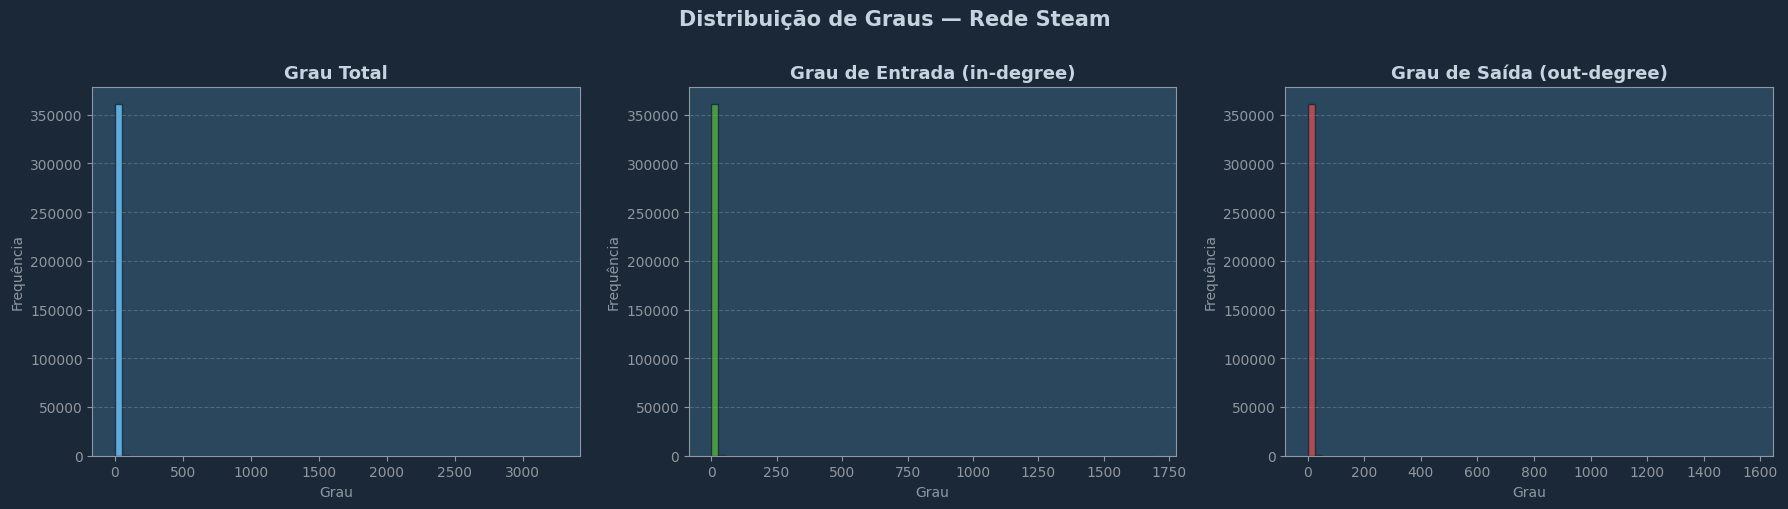

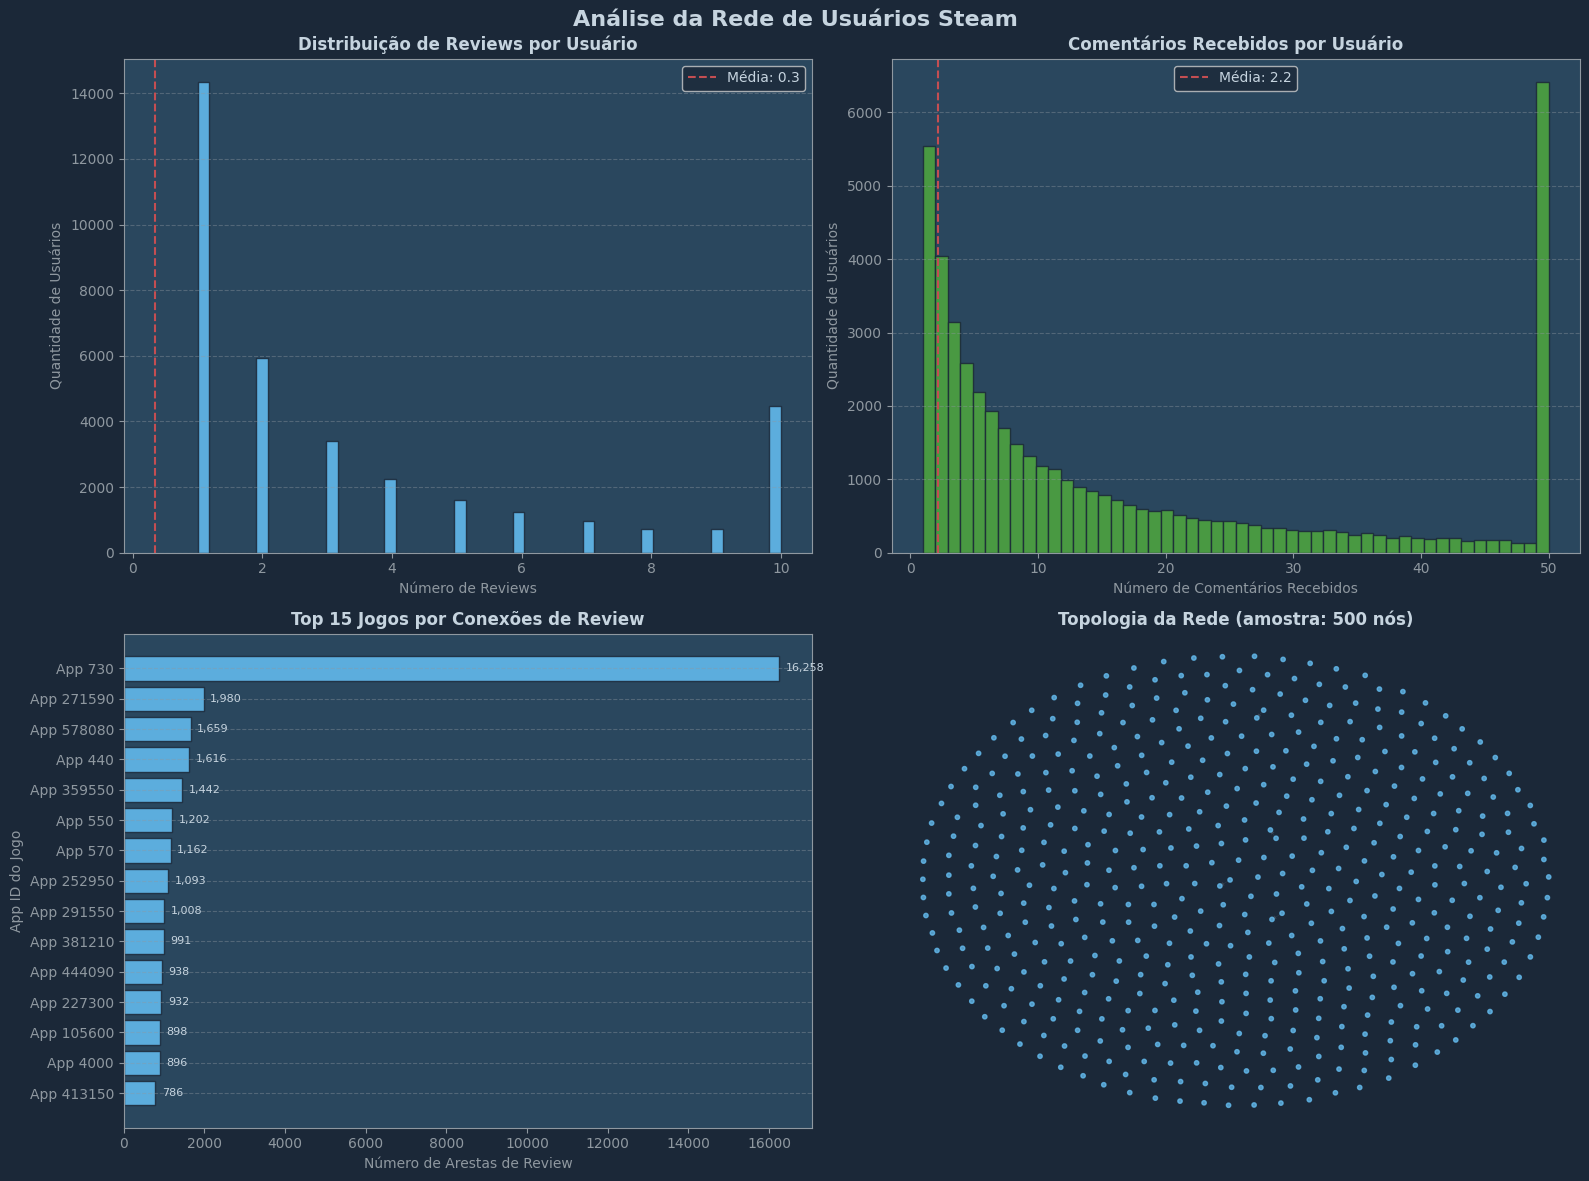

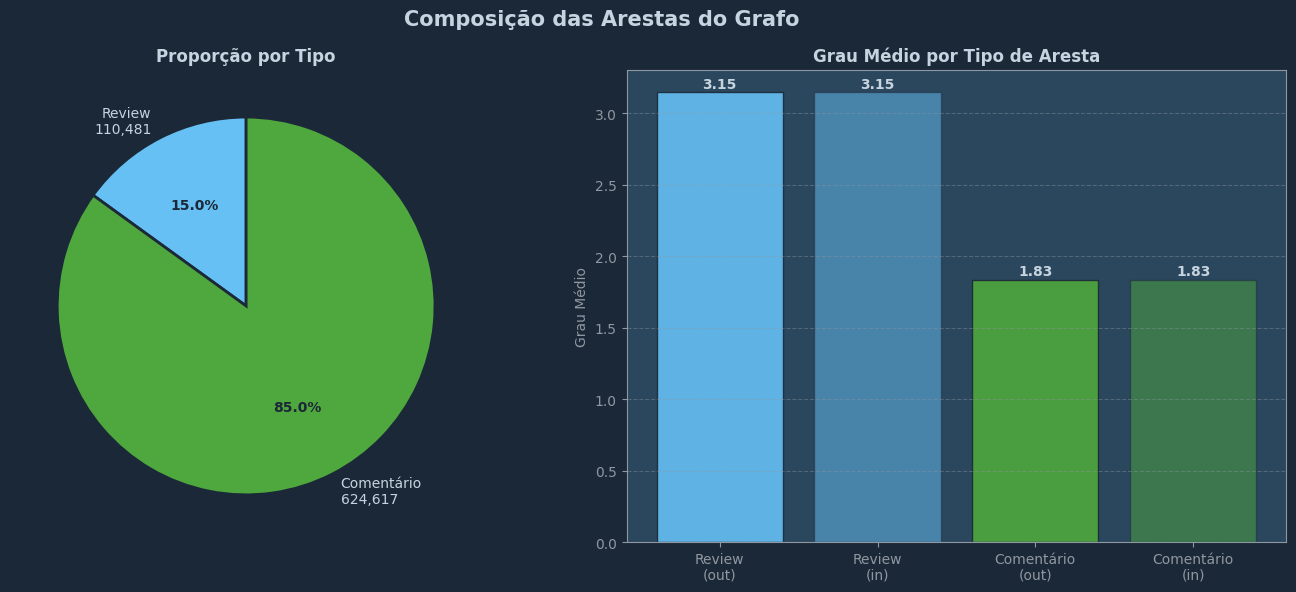

In [12]:
# Carrega o grafo completo (dirigido, todos os tipos de aresta)
G = carregar_grafo(
    nodes_path="../dataset/reviews-comment-graph-v2/nodes.json",
    edges_path="../dataset/reviews-comment-graph-v2/edges.json",
    directed=True,
)

# Estatísticas e histograma de graus
analisar_estatisticas_grafo(G)

# Painéis de análise extra
plotar_analises_extras(G, amostra_grafo=500)

# Distribuição por tipo de aresta
plotar_distribuicao_tipos(G)


  ANÁLISE DE COMPONENTES CONEXAS

Calculando WCC... 16,150 encontrados.
Calculando SCC (pode demorar em grafos grandes)... 73,453 encontrados.

[FRACO]  Componentes fracamente conectados : 16,150
[FORTE]  Componentes fortemente conectados: 73,453

  Maior WCC → 340,767 nós (94.3%)
  Maior SCC → 286,417 nós (79.2%)

  [WCC] Distribuição de tamanhos:
    Singletons  (=1)       :   13,496
    Pequenos    (2–10)     :    2,649
    Médios      (11–1000)  :        4
    Grandes     (>1000)    :        1

  [SCC] Distribuição de tamanhos:
    Singletons  (=1)       :   72,596
    Pequenos    (2–10)     :      847
    Médios      (11–1000)  :        9
    Grandes     (>1000)    :        1

--- TOP 10 MAIORES COMPONENTES (WCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        340,767    730,406     0.000006       4.29
  2             30         30     0.034483       2.00
  3             21         33     0.078571       3

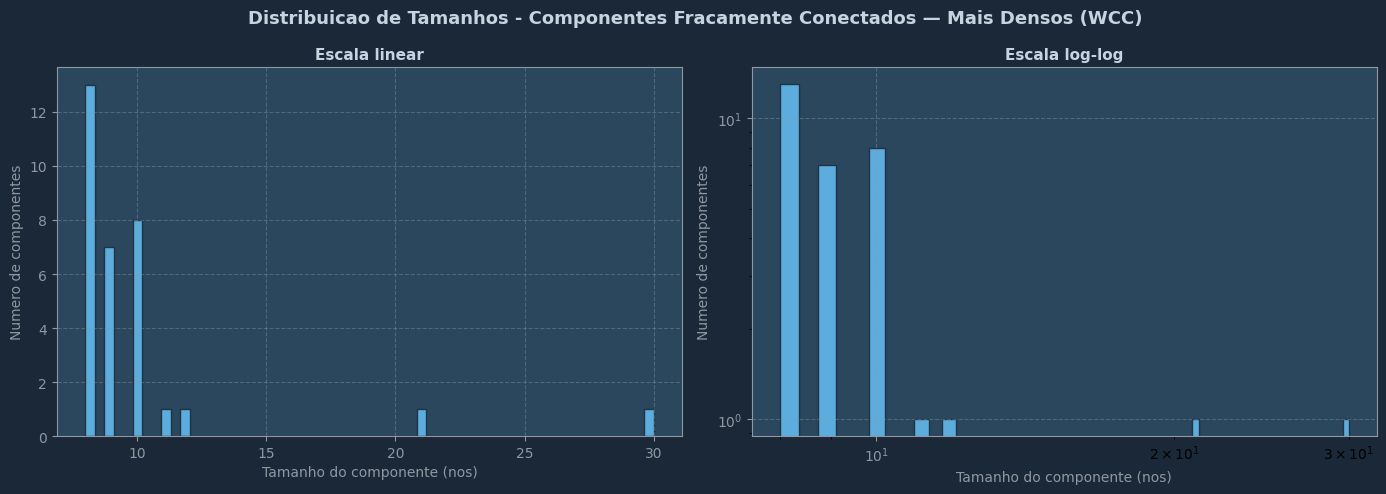

  [1] Salvo: componente_wcc_1.html (9 nos, 17 arestas, dens=0.2361)
  [2] Salvo: componente_wcc_2.html (10 nos, 18 arestas, dens=0.2000)
  [3] Salvo: componente_wcc_3.html (8 nos, 10 arestas, dens=0.1786)
  [4] Salvo: componente_wcc_4.html (8 nos, 9 arestas, dens=0.1607)
  [5] Salvo: componente_wcc_5.html (8 nos, 8 arestas, dens=0.1429)
  [6] Salvo: componente_wcc_6.html (8 nos, 8 arestas, dens=0.1429)
  [7] Salvo: componente_wcc_7.html (8 nos, 8 arestas, dens=0.1429)
  [8] Salvo: componente_wcc_8.html (9 nos, 10 arestas, dens=0.1389)
  [9] Salvo: componente_wcc_9.html (9 nos, 9 arestas, dens=0.1250)
  [10] Salvo: componente_wcc_10.html (9 nos, 9 arestas, dens=0.1250)
  [11] Salvo: componente_wcc_11.html (9 nos, 9 arestas, dens=0.1250)
  [12] Salvo: componente_wcc_12.html (8 nos, 7 arestas, dens=0.1250)

  12 arquivo(s) HTML gerado(s). Abra no browser para visualizacao interativa.

--- TOP 10 MAIORES COMPONENTES (SCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  --------

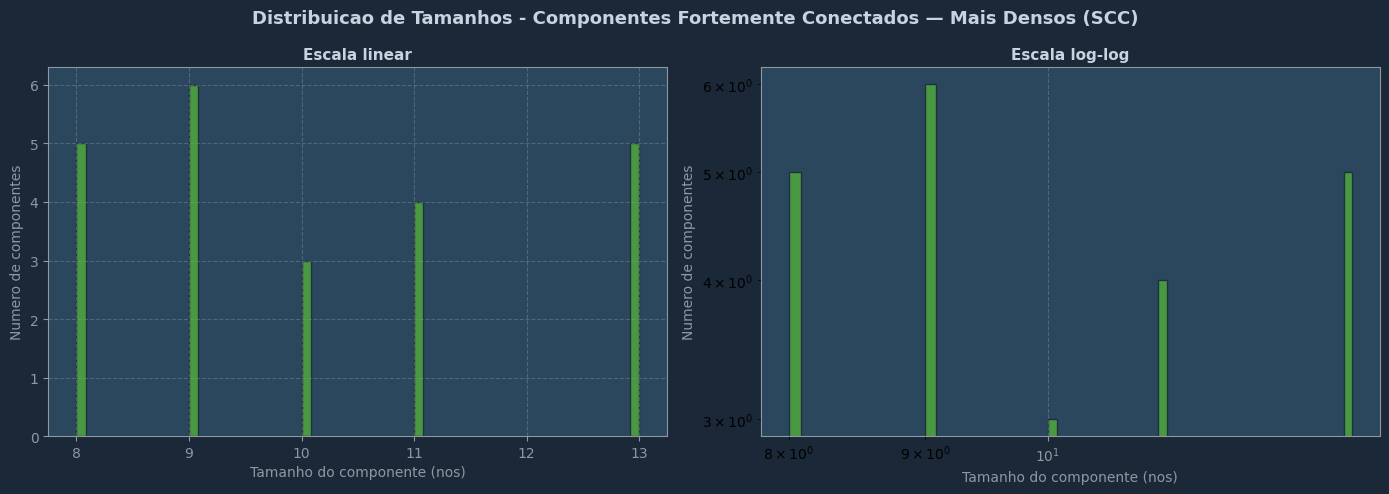

  [1] Salvo: componente_scc_1.html (8 nos, 17 arestas, dens=0.3036)
  [2] Salvo: componente_scc_2.html (9 nos, 17 arestas, dens=0.2361)
  [3] Salvo: componente_scc_3.html (9 nos, 17 arestas, dens=0.2361)
  [4] Salvo: componente_scc_4.html (10 nos, 21 arestas, dens=0.2333)
  [5] Salvo: componente_scc_5.html (9 nos, 16 arestas, dens=0.2222)
  [6] Salvo: componente_scc_6.html (8 nos, 12 arestas, dens=0.2143)
  [7] Salvo: componente_scc_7.html (8 nos, 12 arestas, dens=0.2143)
  [8] Salvo: componente_scc_8.html (9 nos, 14 arestas, dens=0.1944)
  [9] Salvo: componente_scc_9.html (9 nos, 14 arestas, dens=0.1944)
  [10] Salvo: componente_scc_10.html (11 nos, 19 arestas, dens=0.1727)
  [11] Salvo: componente_scc_11.html (10 nos, 15 arestas, dens=0.1667)
  [12] Salvo: componente_scc_12.html (13 nos, 24 arestas, dens=0.1538)

  12 arquivo(s) HTML gerado(s). Abra no browser para visualizacao interativa.


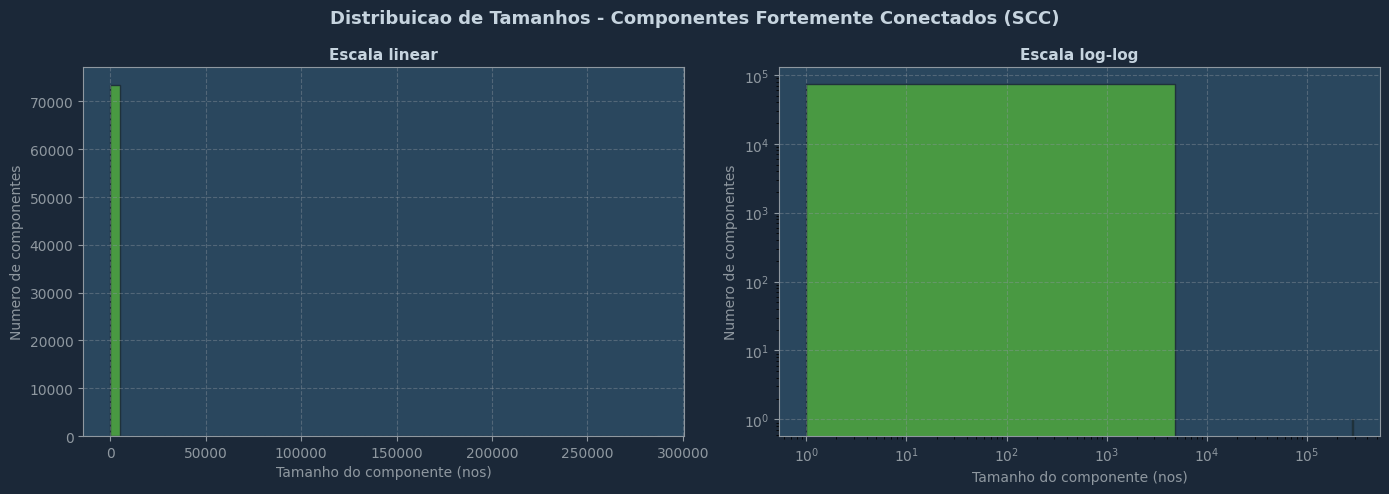

In [17]:
# Se quiser visualizar mais componentes individuais
analisar_componentes_conexas(G, max_visualizar=12)